# Прогноз потребления энергии

**Студенты:** Кунёв, Уколов  
**Задача:** предсказание нагрузки на электросеть по часам  
**Данные:** UCI Electricity Load Diagrams 2011–2014  
**Модели:** ARIMA, Prophet (Facebook), NeuralProphet  
**Логирование экспериментов:** MLflow

Ноутбук выполняется **с начала до конца** (Run All). Перед запуском установите зависимости из `requirements.txt` и при необходимости загрузите данные: `python scripts/download_data.py`.

In [3]:
# === 1. Настройка окружения и воспроизводимость ===
import warnings
warnings.filterwarnings("ignore")

import json
import os
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Фиксация random seed (требование воспроизводимости)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

# Пути проекта
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "LD2011_2014.txt"
MODELS_DIR = PROJECT_ROOT / "models"
MLRUNS_DIR = PROJECT_ROOT / "mlruns"
MODELS_DIR.mkdir(exist_ok=True)
MLRUNS_DIR.mkdir(exist_ok=True)

mlflow.set_tracking_uri(MLRUNS_DIR.as_uri())
mlflow.set_experiment("energy_load_forecasting")

print(f"Project root: {PROJECT_ROOT}")
print(f"Random seed:  {RANDOM_SEED}")

Project root: C:\Users\Антон\Desktop\DESKTOP\КОЛЛЕДЖ\Гневашев\energy-load-forecasting
Random seed:  42


In [4]:
# === 2. Загрузка и подготовка данных ===

def load_hourly_load(data_path: Path, year: int = 2012) -> pd.Series:
    """Загрузка UCI Electricity Load Diagrams, агрегация до часовой суммарной нагрузки."""
    if not data_path.exists():
        raise FileNotFoundError(
            f"Файл не найден: {data_path}\n"
            "Выполните: python scripts/download_data.py"
        )

    print("Чтение данных (может занять 1–3 мин)...")
    df = pd.read_csv(
        data_path,
        sep=";",
        decimal=",",
        parse_dates=[0],
        index_col=0,
        low_memory=False,
    )
    df.index.name = "datetime"

    # Подвыборка одного года для разумного времени обучения
    start, end = f"{year}-01-01", f"{year}-12-31 23:59:59"
    df = df.loc[start:end]

    # 15-мин -> часовая суммарная нагрузка по всем клиентам (МВт)
    hourly = df.resample("h").sum().sum(axis=1)
    hourly.name = "load_mw"
    hourly = hourly.asfreq("h").interpolate(method="linear")
    hourly = hourly.dropna()
    print(f"Период: {hourly.index.min()} — {hourly.index.max()}, точек: {len(hourly)}")
    return hourly


def make_synthetic_hourly(n_hours: int = 8760, seed: int = 42) -> pd.Series:
    """Резервный синтетический ряд с суточной и недельной сезонностью."""
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2012-01-01", periods=n_hours, freq="h")
    t = np.arange(n_hours)
    daily = 800 + 200 * np.sin(2 * np.pi * t / 24 - np.pi / 2)
    weekly = 50 * np.sin(2 * np.pi * t / (24 * 7))
    noise = rng.normal(0, 30, size=n_hours)
    values = daily + weekly + noise
    return pd.Series(values, index=idx, name="load_mw")


try:
    series = load_hourly_load(DATA_PATH, year=2012)
    data_source = "UCI Electricity Load Diagrams (2012)"
except FileNotFoundError as e:
    print(f"WARNING: {e}")
    print("Используется синтетический ряд для демонстрации пайплайна.")
    series = make_synthetic_hourly(seed=RANDOM_SEED)
    data_source = "Synthetic (fallback)"

ts_df = series.reset_index()
ts_df.columns = ["ds", "y"]
ts_df.head()

Чтение данных (может занять 1–3 мин)...
Период: 2012-01-01 00:00:00 — 2012-12-31 23:00:00, точек: 8784


,ds,y
0,2012-01-01 00:00:00,416921.975284
1,2012-01-01 01:00:00,450201.475472
2,2012-01-01 02:00:00,443720.990509
3,2012-01-01 03:00:00,424767.019885
4,2012-01-01 04:00:00,414161.676663


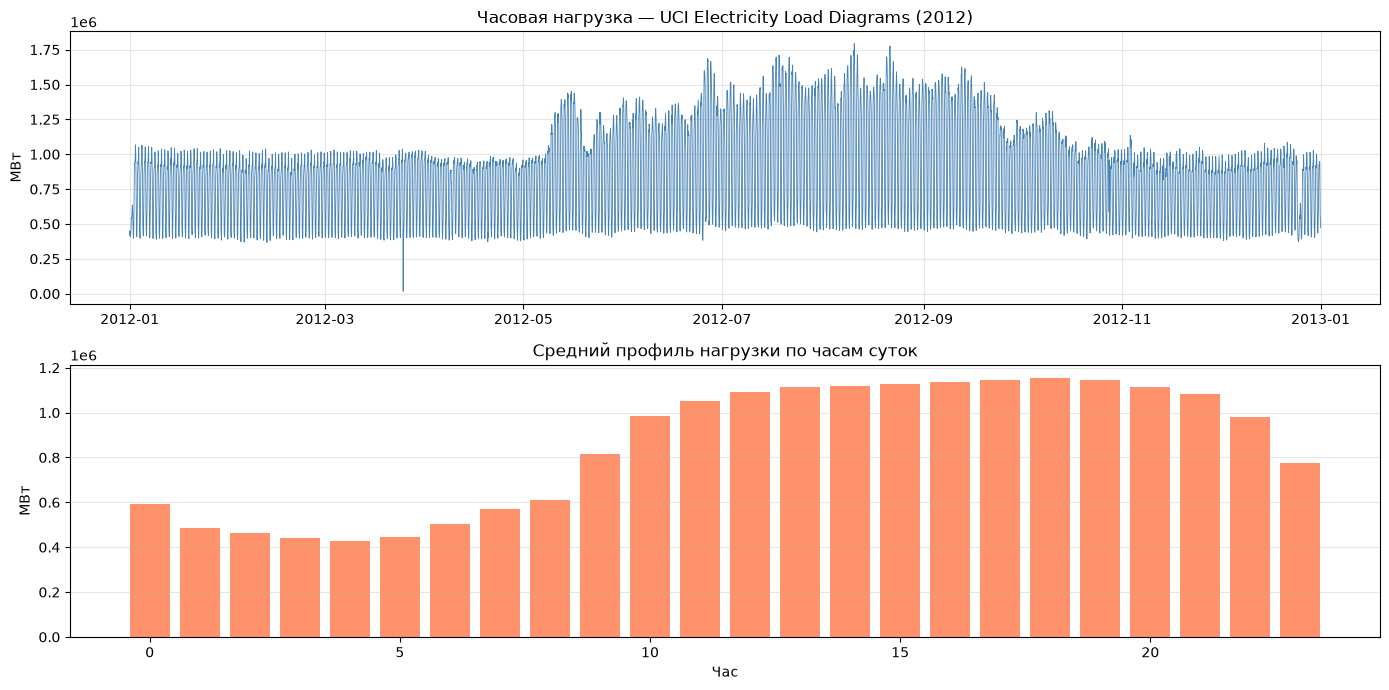

Min: 17148.4 MW | Max: 1792595.0 MW | Mean: 849269.7 MW


In [5]:
# === 3. EDA ===
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

sample = ts_df.set_index("ds")["y"]
axes[0].plot(sample.index, sample.values, linewidth=0.6, color="steelblue")
axes[0].set_title(f"Часовая нагрузка — {data_source}")
axes[0].set_ylabel("МВт")
axes[0].grid(alpha=0.3)

# Средний профиль по часам суток
hourly_profile = sample.groupby(sample.index.hour).mean()
axes[1].bar(hourly_profile.index, hourly_profile.values, color="coral", alpha=0.85)
axes[1].set_title("Средний профиль нагрузки по часам суток")
axes[1].set_xlabel("Час")
axes[1].set_ylabel("МВт")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"Min: {sample.min():.1f} MW | Max: {sample.max():.1f} MW | Mean: {sample.mean():.1f} MW")

In [6]:
# === 4. Train / Test split (временной) ===
FORECAST_HORIZON = 168  # 7 суток вперёд (часов)

train_df = ts_df.iloc[:-FORECAST_HORIZON].copy()
test_df = ts_df.iloc[-FORECAST_HORIZON:].copy()

print(f"Train: {len(train_df)} часов ({train_df['ds'].min()} — {train_df['ds'].max()})")
print(f"Test:  {len(test_df)} часов ({test_df['ds'].min()} — {test_df['ds'].max()})")

y_train = train_df["y"].values
y_test = test_df["y"].values

Train: 8616 часов (2012-01-01 00:00:00 — 2012-12-24 23:00:00)
Test:  168 часов (2012-12-25 00:00:00 — 2012-12-31 23:00:00)


In [7]:
# === 5. Функции метрик ===

def evaluate_forecast(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
    return {"rmse": rmse, "mae": mae, "mape": mape}


results = []  # сводная таблица экспериментов

In [8]:
# === 6. ARIMA — эксперименты с гиперпараметрами ===
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

arima_configs = [
    {"order": (1, 1, 1), "label": "ARIMA(1,1,1)"},
    {"order": (2, 1, 2), "label": "ARIMA(2,1,2)"},
    {"order": (3, 1, 1), "label": "ARIMA(3,1,1)"},
]

arima_models = {}

for cfg in arima_configs:
    order = cfg["order"]
    label = cfg["label"]

    with mlflow.start_run(run_name=label):
        mlflow.log_param("model", "ARIMA")
        mlflow.log_param("order", str(order))
        mlflow.log_param("forecast_horizon", FORECAST_HORIZON)

        model = ARIMA(y_train, order=order)
        fitted = model.fit()

        forecast = fitted.forecast(steps=FORECAST_HORIZON)

        # ✅ FIX: убрать .values и привести к numpy
        forecast = np.asarray(forecast)
        y_true = np.asarray(y_test)

        metrics = evaluate_forecast(y_true, forecast)

        mlflow.log_metrics(metrics)
        arima_models[label] = fitted

        row = {"model": label, **metrics, "order": str(order)}
        results.append(row)

        print(
            f"{label}: RMSE={metrics['rmse']:.2f}, "
            f"MAE={metrics['mae']:.2f}, MAPE={metrics['mape']:.2f}%"
        )

best_arima_label = min(
    [r for r in results if r["model"].startswith("ARIMA")],
    key=lambda x: x["rmse"],
)["model"]

print(f"\nЛучший ARIMA: {best_arima_label}")

ARIMA(1,1,1): RMSE=460016.96, MAE=404683.05, MAPE=53.10%
ARIMA(2,1,2): RMSE=468126.92, MAE=413591.64, MAPE=54.49%
ARIMA(3,1,1): RMSE=469306.16, MAE=414881.19, MAPE=54.69%

Лучший ARIMA: ARIMA(1,1,1)


In [9]:
# === 7. Prophet — эксперименты с гиперпараметрами ===
from prophet import Prophet
import mlflow

prophet_configs = [
    {"changepoint_prior_scale": 0.05, "seasonality_mode": "additive", "label": "Prophet_cps0.05_add"},
    {"changepoint_prior_scale": 0.5, "seasonality_mode": "additive", "label": "Prophet_cps0.5_add"},
    {"changepoint_prior_scale": 0.05, "seasonality_mode": "multiplicative", "label": "Prophet_cps0.05_mul"},
]

prophet_models = {}

for cfg in prophet_configs:
    label = cfg["label"]
    with mlflow.start_run(run_name=label):
        mlflow.log_param("model", "Prophet")
        mlflow.log_param("changepoint_prior_scale", cfg["changepoint_prior_scale"])
        mlflow.log_param("seasonality_mode", cfg["seasonality_mode"])
        mlflow.log_param("forecast_horizon", FORECAST_HORIZON)

        m = Prophet(
            changepoint_prior_scale=cfg["changepoint_prior_scale"],
            seasonality_mode=cfg["seasonality_mode"],
            daily_seasonality=True,
            weekly_seasonality=True,
            yearly_seasonality=True,
        )
        m.fit(train_df)

        future = test_df[["ds"]].copy()
        forecast = m.predict(future)
        y_pred = forecast["yhat"].values
        metrics = evaluate_forecast(y_test, y_pred)

        mlflow.log_metrics(metrics)
        prophet_models[label] = m

        results.append({"model": label, **metrics,
                        "changepoint_prior_scale": cfg["changepoint_prior_scale"],
                        "seasonality_mode": cfg["seasonality_mode"]})
        print(f"{label}: RMSE={metrics['rmse']:.2f}, MAE={metrics['mae']:.2f}, MAPE={metrics['mape']:.2f}%")

best_prophet_label = min(
    [r for r in results if r["model"].startswith("Prophet")],
    key=lambda x: x["rmse"],
)["model"]
print(f"\nЛучший Prophet: {best_prophet_label}")

21:40:38 - cmdstanpy - INFO - Chain [1] start processing
21:40:39 - cmdstanpy - INFO - Chain [1] done processing


Prophet_cps0.05_add: RMSE=181788.98, MAE=127321.44, MAPE=18.90%


21:40:40 - cmdstanpy - INFO - Chain [1] start processing
21:40:41 - cmdstanpy - INFO - Chain [1] done processing


Prophet_cps0.5_add: RMSE=170316.70, MAE=117361.02, MAPE=18.13%


21:40:42 - cmdstanpy - INFO - Chain [1] start processing
21:40:45 - cmdstanpy - INFO - Chain [1] done processing


Prophet_cps0.05_mul: RMSE=126295.65, MAE=74140.41, MAPE=13.33%

Лучший Prophet: Prophet_cps0.05_mul


In [ ]:
# === 8. NeuralProphet — эксперименты с гиперпараметрами ===
from neuralprophet import NeuralProphet

np_configs = [
    {"learning_rate": 0.01, "epochs": 50, "n_lags": 24, "label": "NP_lr0.01_ep50_lag24"},
    {"learning_rate": 0.001, "epochs": 80, "n_lags": 48, "label": "NP_lr0.001_ep80_lag48"},
    {"learning_rate": 0.01, "epochs": 100, "n_lags": 72, "label": "NP_lr0.01_ep100_lag72"},
]

np_models = {}

for cfg in np_configs:
    label = cfg["label"]
    with mlflow.start_run(run_name=label):
        mlflow.log_param("model", "NeuralProphet")
        mlflow.log_param("learning_rate", cfg["learning_rate"])
        mlflow.log_param("epochs", cfg["epochs"])
        mlflow.log_param("n_lags", cfg["n_lags"])
        mlflow.log_param("forecast_horizon", FORECAST_HORIZON)

        m = NeuralProphet(
            n_lags=cfg["n_lags"],
            n_forecasts=FORECAST_HORIZON,
            learning_rate=cfg["learning_rate"],
            epochs=cfg["epochs"],
            batch_size=64,
        )

        m.fit(train_df, freq="h")

        # raw=True: step{k} — прогноз на (k+1)-й час вперёд от последней точки train
        forecast = m.predict(train_df, raw=True)
        last_row = forecast.iloc[-1]
        y_pred = np.array(
            [last_row[f"step{i}"] for i in range(FORECAST_HORIZON)],
            dtype=float,
        )
        metrics = evaluate_forecast(y_test, y_pred)

        mlflow.log_metrics(metrics)
        np_models[label] = m

        results.append({"model": label, **metrics,
                        "learning_rate": cfg["learning_rate"],
                        "epochs": cfg["epochs"],
                        "n_lags": cfg["n_lags"]})
        print(f"{label}: RMSE={metrics['rmse']:.2f}, MAE={metrics['mae']:.2f}, MAPE={metrics['mape']:.2f}%")

best_np_label = min(
    [r for r in results if r["model"].startswith("NP_")],
    key=lambda x: x["rmse"],
)["model"]
print(f"\nЛучший NeuralProphet: {best_np_label}")

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.988% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - h
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling yearly seasonality. Run NeuralProphet with yearly_seasonality=True to override this.


Training: 0it [00:00, ?it/s]

=== Итоговое сравнение (сортировка по RMSE) ===


,model,rmse,mae,mape,order,changepoint_prior_scale,seasonality_mode,learning_rate,epochs,n_lags
0,Prophet_cps0.05_mul,126295.647280,74140.410082,13.326024,NaN,0.05,multiplicative,NaN,NaN,NaN
1,NP_lr0.01_ep100_lag72,130116.004001,80652.781966,14.174025,NaN,NaN,NaN,0.010,100.0,72.0
2,NP_lr0.001_ep80_lag48,133034.375020,74521.915732,12.788461,NaN,NaN,NaN,0.001,80.0,48.0
3,NP_lr0.01_ep50_lag24,143450.159600,85881.378272,14.483541,NaN,NaN,NaN,0.010,50.0,24.0
4,Prophet_cps0.5_add,170316.698874,117361.015024,18.132832,NaN,0.50,additive,NaN,NaN,NaN
5,Prophet_cps0.05_add,181788.976734,127321.439586,18.901578,NaN,0.05,additive,NaN,NaN,NaN
6,"ARIMA(1,1,1)",460016.959520,404683.049182,53.100910,"(1, 1, 1)",NaN,NaN,NaN,NaN,NaN
7,"ARIMA(2,1,2)",468126.917066,413591.638268,54.490143,"(2, 1, 2)",NaN,NaN,NaN,NaN,NaN
8,"ARIMA(3,1,1)",469306.164575,414881.185325,54.690899,"(3, 1, 1)",NaN,NaN,NaN,NaN,NaN


WARNING - (NP.forecaster.predict) - Raw forecasts are incompatible with plotting utilities
INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.988% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - h
INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.988% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - h



Лучшая модель: Prophet_cps0.05_mul | RMSE=126295.65 | MAPE=13.33%


Predicting: 131it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


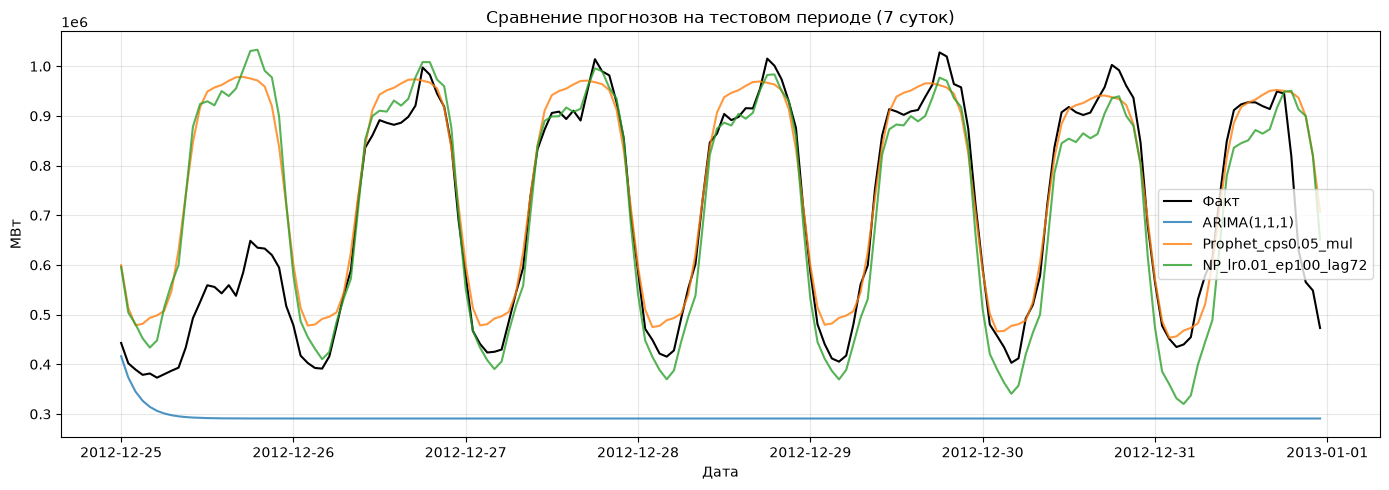

In [ ]:
# === 9. Сравнение моделей ===
results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
print("=== Итоговое сравнение (сортировка по RMSE) ===")
display(results_df)

best_row = results_df.iloc[0]
print(f"\nЛучшая модель: {best_row['model']} | RMSE={best_row['rmse']:.2f} | MAPE={best_row['mape']:.2f}%")

# Визуализация лучших прогнозов каждого семейства
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_df["ds"], y_test, label="Факт", color="black", linewidth=1.5)

# ARIMA best
best_arima = arima_models[best_arima_label]
pred_arima = np.asarray(best_arima.forecast(steps=FORECAST_HORIZON))
ax.plot(test_df["ds"], pred_arima, label=best_arima_label, alpha=0.8)

# Prophet best
best_prophet = prophet_models[best_prophet_label]
fc_p = best_prophet.predict(test_df[["ds"]])
ax.plot(test_df["ds"], fc_p["yhat"].values, label=best_prophet_label, alpha=0.8)

# NeuralProphet best
best_np = np_models[best_np_label]
fc_np = best_np.predict(train_df, raw=True)
pred_np = np.array(
    [fc_np.iloc[-1][f"step{i}"] for i in range(FORECAST_HORIZON)],
    dtype=float,
)
ax.plot(test_df["ds"], pred_np, label=best_np_label, alpha=0.8)

ax.set_title("Сравнение прогнозов на тестовом периоде (7 суток)")
ax.set_xlabel("Дата")
ax.set_ylabel("МВт")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# === 10. Сохранение лучшей модели ===
from prophet.serialize import model_to_json

def save_best_model(best_name: str, models_dir: Path) -> Path:
    meta = {
        "model_name": best_name,
        "random_seed": RANDOM_SEED,
        "forecast_horizon": FORECAST_HORIZON,
        "data_source": data_source,
        "metrics": results_df.iloc[0].to_dict(),
    }

    if best_name.startswith("ARIMA"):
        artifact = arima_models[best_name]
        meta["model_type"] = "arima"
        model_path = models_dir / "best_model.pkl"
        joblib.dump(artifact, model_path)
    elif best_name.startswith("Prophet"):
        artifact = prophet_models[best_name]
        meta["model_type"] = "prophet"
        model_path = models_dir / "best_model.json"
        with open(model_path, "w", encoding="utf-8") as f:
            f.write(model_to_json(artifact))
    else:
        artifact = np_models[best_name]
        meta["model_type"] = "neuralprophet"
        model_path = models_dir / "best_model"
        artifact.save(str(model_path))

    meta_path = models_dir / "best_model_meta.json"
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False, default=str)

    print(f"Сохранено: {model_path}")
    print(f"Метаданные: {meta_path}")
    return model_path


model_path = save_best_model(best_row["model"], MODELS_DIR)
results_df.to_csv(MODELS_DIR / "experiment_results.csv", index=False)
print("Результаты экспериментов: models/experiment_results.csv")

Сохранено: C:\Users\Антон\Projects\energy-load-forecasting\models\best_model.json
Метаданные: C:\Users\Антон\Projects\energy-load-forecasting\models\best_model_meta.json
Результаты экспериментов: models/experiment_results.csv


Загружена модель: Prophet_cps0.05_mul (prophet)
Метрики на тесте: RMSE=126295.65, MAPE=13.33%

Контекст (новые наблюдения): 2012-12-24 00:00:00 — 2012-12-24 23:00:00


00:36:19 - cmdstanpy - INFO - Chain [1] start processing
00:36:22 - cmdstanpy - INFO - Chain [1] done processing



=== Прогноз на новых данных (следующие 24 часа) ===


,ds,yhat
0,2012-12-25 00:00:00,593641.245558
1,2012-12-25 01:00:00,508300.430243
2,2012-12-25 02:00:00,473856.064851
3,2012-12-25 03:00:00,476720.118250
4,2012-12-25 04:00:00,488516.805513
5,2012-12-25 05:00:00,493507.103931
6,2012-12-25 06:00:00,502619.754679
7,2012-12-25 07:00:00,541408.343193
8,2012-12-25 08:00:00,623484.060437
9,2012-12-25 09:00:00,734180.581202


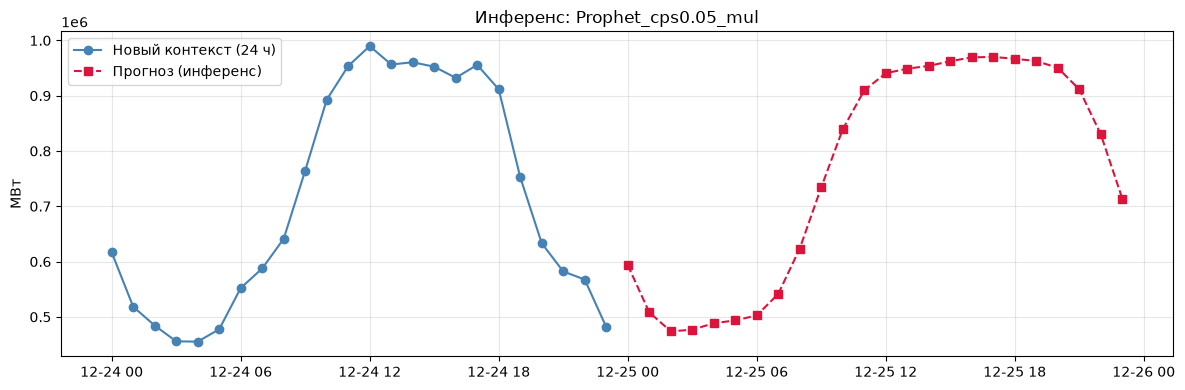


Инференс успешно выполнен.


In [ ]:
# === 11. ИНФЕРЕНС: загрузка модели и предсказание на новых данных ===

# Симулируем поступление новых наблюдений (последние 24 ч train + прогноз на 24 ч вперёд)

INFERENCE_HORIZON = 24

with open(MODELS_DIR / "best_model_meta.json", encoding="utf-8") as f:
    saved_meta = json.load(f)

model_type = saved_meta["model_type"]
print(f"Загружена модель: {saved_meta['model_name']} ({model_type})")
print(f"Метрики на тесте: RMSE={saved_meta['metrics']['rmse']:.2f}, MAPE={saved_meta['metrics']['mape']:.2f}%")

# «Новые» данные — последние 24 часа обучающей выборки
new_context = train_df.tail(24).copy()
print(f"\nКонтекст (новые наблюдения): {new_context['ds'].min()} — {new_context['ds'].max()}")

if model_type == "arima":
    loaded = joblib.load(MODELS_DIR / "best_model.pkl")
    extended_y = pd.concat([train_df["y"], new_context["y"]], ignore_index=True).values
    best_order_str = results_df[results_df["model"] == saved_meta["model_name"]]["order"].iloc[0]
    order = eval(best_order_str)
    refitted = ARIMA(extended_y, order=order).fit()
    inference_pred = refitted.forecast(steps=INFERENCE_HORIZON)
    future_dates = pd.date_range(new_context["ds"].iloc[-1] + pd.Timedelta(hours=1), periods=INFERENCE_HORIZON, freq="h")

elif model_type == "prophet":
    best_cfg = results_df[results_df["model"] == saved_meta["model_name"]].iloc[0]
    loaded = Prophet(
        changepoint_prior_scale=best_cfg["changepoint_prior_scale"],
        seasonality_mode=best_cfg["seasonality_mode"],
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True,
    )
    extended = pd.concat([train_df, new_context], ignore_index=True)
    loaded.fit(extended)
    future_inf = pd.DataFrame({
        "ds": pd.date_range(new_context["ds"].iloc[-1] + pd.Timedelta(hours=1),
                            periods=INFERENCE_HORIZON, freq="h")
    })
    fc_inf = loaded.predict(future_inf)
    inference_pred = fc_inf["yhat"].values
    future_dates = future_inf["ds"]

else:  # neuralprophet
    loaded = NeuralProphet.load(str(MODELS_DIR / "best_model"))
    extended = pd.concat([train_df, new_context], ignore_index=True)
    loaded.fit(extended, freq="h")
    fc_inf = loaded.predict(extended, raw=True)
    last_row = fc_inf.iloc[-1]
    inference_pred = np.array(
        [last_row[f"step{i}"] for i in range(INFERENCE_HORIZON)],
        dtype=float,
    )
    last_date = extended["ds"].iloc[-1]
    future_dates = pd.date_range(last_date + pd.Timedelta(hours=1), periods=INFERENCE_HORIZON, freq="h")

inference_df = pd.DataFrame({"ds": future_dates, "yhat": inference_pred})
print("\n=== Прогноз на новых данных (следующие 24 часа) ===")
display(inference_df.head(10))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(new_context["ds"], new_context["y"], "o-", label="Новый контекст (24 ч)", color="steelblue")
ax.plot(inference_df["ds"], inference_df["yhat"], "s--", label="Прогноз (инференс)", color="crimson")
ax.set_title(f"Инференс: {saved_meta['model_name']}")
ax.set_ylabel("МВт")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nИнференс успешно выполнен.")

## Выводы

1. **Лучшая модель** определяется по минимальному RMSE на 7-суточном тестовом горизонте (см. таблицу выше и `models/experiment_results.csv`).
2. **MLflow** — все 9 экспериментов (3×ARIMA, 3×Prophet, 3×NeuralProphet) залогированы в `mlruns/`. Запуск UI: `mlflow ui --backend-store-uri mlruns`.
3. **Инференс** — модель загружается из `models/`, принимает новый 24-часовой контекст и строит прогноз на 24 ч вперёд.
4. Подробный отчёт: см. `REPORT.md` в корне проекта.